#1. Importação e Configuração

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

###1.1 Método para limpar simbolos, caracteres, etc

In [137]:
# Função para tratar os símbolos do IBGE (-, ..., X, etc)
def limpar_ibge(valor):
    if pd.isna(valor): return np.nan
    s = str(valor).strip()
    if s in ['-', '0', '0,0']: return 0.0
    if s in ['...', '..', 'X']: return np.nan
    # Remove pontos de milhar e ajusta a vírgula decimal
    return float(s.replace('.', '').replace(',', '.'))



#2. Carregamento e Análise Inicial
### As tabelas do IBGE costumam vir com metadados nas primeiras linhas e caracteres específicos para dados ausentes. Observar e tratar esses requisitos são fundamentais para uma aplicação segura e consistente de ciência de dados.

### 2.1 Carregamento frames

In [138]:
df_agua_raw = pd.read_excel('/content/ret_tratamento_tabela1773.xlsx')
df_int_raw = pd.read_excel('/content/ret_internacoes_tabela898.xlsx')




### 2.2 Visualização e informações dos frames

In [139]:
df_agua_raw.info()
df_agua_raw.describe()
df_agua_raw.head()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Municipios                               5571 non-null   object
 1   Volume total de água com tratamento      5570 non-null   object
 2   Convencional                             5570 non-null   object
 3   Não-convencional                         5570 non-null   object
 4   Simples desinfecção (cloração e outros)  5570 non-null   object
 5   Sem tratamento                           5570 non-null   object
dtypes: object(6)
memory usage: 261.3+ KB


,Municipios,Volume total de água com tratamento,Convencional,Não-convencional,Simples desinfecção (cloração e outros),Sem tratamento
0,Alta Floresta D'Oeste (RO),400,400,-,-,-
1,Ariquemes (RO),5472,5472,-,-,-
2,Cabixi (RO),-,-,-,-,-
3,Cacoal (RO),26688,26688,-,-,-
4,Cerejeiras (RO),-,-,-,-,-


In [140]:
df_int_raw.info()
df_int_raw.describe()
df_int_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Estados                                     28 non-null     object 
 1   Total                                       27 non-null     float64
 2   De transmissão feco-oral                    27 non-null     float64
 3   Tansmitidas por inseto vetor                27 non-null     float64
 4   Transmitidas através do contato com a água  27 non-null     float64
 5   Relacionadas com a higiene                  27 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.4+ KB


,Estados,Total,De transmissão feco-oral,Tansmitidas por inseto vetor,Transmitidas através do contato com a água,Relacionadas com a higiene
0,Rondônia,295.3,190.8,100.6,2.1,0.4
1,Acre,247.6,187.1,55.6,3.6,0.6
2,Amazonas,136.2,120.3,14.1,0.9,0.1
3,Roraima,222.9,149.0,70.0,0.0,0.2
4,Pará,484.6,437.9,44.7,1.2,0.2


### 2.3 Renomear as colunas dos framese visualizar dados

In [141]:
df_agua_raw.columns = ['Municipio', 'Vol_Tratamento_Total', 'Convencional', 'Nao_Convencional', 'Simples_Desinfeccao', 'Sem_Tratamento']
df_int_raw.columns = ['Estado', 'Internacao_Total', 'Internacao_Feco_Oral', 'Internacao_Inseto_Vetor', 'Internacao_Contato_Agua', 'Internacao_Falta_Higiene']


In [142]:
df_agua_raw.head()

,Municipio,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento
0,Alta Floresta D'Oeste (RO),400,400,-,-,-
1,Ariquemes (RO),5472,5472,-,-,-
2,Cabixi (RO),-,-,-,-,-
3,Cacoal (RO),26688,26688,-,-,-
4,Cerejeiras (RO),-,-,-,-,-


In [143]:
df_int_raw.head()

,Estado,Internacao_Total,Internacao_Feco_Oral,Internacao_Inseto_Vetor,Internacao_Contato_Agua,Internacao_Falta_Higiene
0,Rondônia,295.3,190.8,100.6,2.1,0.4
1,Acre,247.6,187.1,55.6,3.6,0.6
2,Amazonas,136.2,120.3,14.1,0.9,0.1
3,Roraima,222.9,149.0,70.0,0.0,0.2
4,Pará,484.6,437.9,44.7,1.2,0.2


#3. Transformação frame Tratamento Água: Cidades para Região (UF)
###3.1 Aqui extraímos a sigla do estado que está entre parênteses na coluna de municípios e realizamos a agregação. Extrair a UF do nome do Município: "Cidade (UF)"

In [144]:
df_agua_raw['UF'] = df_agua_raw['Municipio'].str.extract(r'\((.*?)\)')
df_agua_raw = df_agua_raw.dropna(subset=['UF'])


In [145]:
df_agua_raw.info()
df_agua_raw.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5570 entries, 0 to 5569
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Municipio             5570 non-null   object
 1   Vol_Tratamento_Total  5570 non-null   object
 2   Convencional          5570 non-null   object
 3   Nao_Convencional      5570 non-null   object
 4   Simples_Desinfeccao   5570 non-null   object
 5   Sem_Tratamento        5570 non-null   object
 6   UF                    5570 non-null   object
dtypes: object(7)
memory usage: 348.1+ KB


,Municipio,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento,UF
0,Alta Floresta D'Oeste (RO),400,400,-,-,-,RO
1,Ariquemes (RO),5472,5472,-,-,-,RO
2,Cabixi (RO),-,-,-,-,-,RO
3,Cacoal (RO),26688,26688,-,-,-,RO
4,Cerejeiras (RO),-,-,-,-,-,RO


### 3.2 Limpar os dados numéricos das colunas de tratamento de água

In [146]:
cols_tratamento_agua = ['Vol_Tratamento_Total', 'Convencional', 'Nao_Convencional', 'Simples_Desinfeccao', 'Sem_Tratamento']

for col in cols_tratamento_agua:
    df_agua_raw[col] = df_agua_raw[col].apply(limpar_ibge)


### 3.3 Visualização e informações dos frames

In [147]:
df_agua_raw.info()
df_agua_raw.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5570 entries, 0 to 5569
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Municipio             5570 non-null   object 
 1   Vol_Tratamento_Total  5570 non-null   float64
 2   Convencional          5570 non-null   float64
 3   Nao_Convencional      5570 non-null   float64
 4   Simples_Desinfeccao   5570 non-null   float64
 5   Sem_Tratamento        5570 non-null   float64
 6   UF                    5570 non-null   object 
dtypes: float64(5), object(2)
memory usage: 348.1+ KB


,Municipio,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento,UF
0,Alta Floresta D'Oeste (RO),400.0,400.0,0.0,0.0,0.0,RO
1,Ariquemes (RO),5472.0,5472.0,0.0,0.0,0.0,RO
2,Cabixi (RO),0.0,0.0,0.0,0.0,0.0,RO
3,Cacoal (RO),26688.0,26688.0,0.0,0.0,0.0,RO
4,Cerejeiras (RO),0.0,0.0,0.0,0.0,0.0,RO


### 3.4 Agrupando por UF e somando os valores


In [148]:
df_agua_uf = df_agua_raw.groupby('UF')[cols_tratamento_agua].sum().reset_index()



### 3.5 Visualização e informações dos frames

In [149]:
df_agua_uf.info()
df_agua_uf.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UF                    27 non-null     object 
 1   Vol_Tratamento_Total  27 non-null     float64
 2   Convencional          27 non-null     float64
 3   Nao_Convencional      27 non-null     float64
 4   Simples_Desinfeccao   27 non-null     float64
 5   Sem_Tratamento        27 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.4+ KB


,UF,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento
0,AC,171337.0,147131.0,0.0,24205.0,0.0
1,AL,546898.0,175472.0,66753.0,193953.0,110.0
2,AM,749550.0,562677.0,8010.0,178863.0,174994.0
3,AP,153640.0,120533.0,0.0,33107.0,2155.0
4,BA,2310335.0,1865778.0,147309.0,287568.0,314295.0


#4. Preparação da Base de Internações e Merge

In [150]:
df_int_raw.head()

,Estado,Internacao_Total,Internacao_Feco_Oral,Internacao_Inseto_Vetor,Internacao_Contato_Agua,Internacao_Falta_Higiene
0,Rondônia,295.3,190.8,100.6,2.1,0.4
1,Acre,247.6,187.1,55.6,3.6,0.6
2,Amazonas,136.2,120.3,14.1,0.9,0.1
3,Roraima,222.9,149.0,70.0,0.0,0.2
4,Pará,484.6,437.9,44.7,1.2,0.2


In [151]:
mapa_uf = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM', 'Bahia': 'BA',
    'Ceará': 'CE', 'Distrito Federal': 'DF', 'Espírito Santo': 'ES', 'Goiás': 'GO',
    'Maranhão': 'MA', 'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS', 'Minas Gerais': 'MG',
    'Pará': 'PA', 'Paraíba': 'PB', 'Paraná': 'PR', 'Pernambuco': 'PE', 'Piauí': 'PI',
    'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN', 'Rio Grande do Sul': 'RS',
    'Rondônia': 'RO', 'Roraima': 'RR', 'Santa Catarina': 'SC', 'São Paulo': 'SP',
    'Sergipe': 'SE', 'Tocantins': 'TO'
}

df_int_raw['UF'] = df_int_raw['Estado'].map(mapa_uf)
cols_int = ['Internacao_Total', 'Internacao_Feco_Oral', 'Internacao_Inseto_Vetor', 'Internacao_Contato_Agua', 'Internacao_Falta_Higiene']

for col in cols_int:
    df_int_raw[col] = df_int_raw[col].apply(limpar_ibge)

df_int_raw.head()
df_int_raw = df_int_raw[['UF', 'Estado', 'Internacao_Feco_Oral', 'Internacao_Inseto_Vetor', 'Internacao_Contato_Agua', 'Internacao_Falta_Higiene', 'Internacao_Total']]
df_int_raw.head()

,UF,Estado,Internacao_Feco_Oral,Internacao_Inseto_Vetor,Internacao_Contato_Agua,Internacao_Falta_Higiene,Internacao_Total
0,RO,Rondônia,1908.0,1006.0,21.0,4.0,2953.0
1,AC,Acre,1871.0,556.0,36.0,6.0,2476.0
2,AM,Amazonas,1203.0,141.0,9.0,1.0,1362.0
3,RR,Roraima,1490.0,700.0,0.0,2.0,2229.0
4,PA,Pará,4379.0,447.0,12.0,2.0,4846.0


### 4.1 Fazendo o Merge nos frames

In [152]:
df_merged = pd.merge(df_agua_uf, df_int_raw[['UF', 'Estado', 'Internacao_Feco_Oral', 'Internacao_Total']], on='UF')

df_merged = df_merged[['UF', 'Estado', 'Vol_Tratamento_Total', 'Convencional', 'Nao_Convencional', 'Simples_Desinfeccao', 'Sem_Tratamento', 'Internacao_Feco_Oral', 'Internacao_Total']]
display(df_merged)
df_merged.info()
df_merged.describe()

,UF,Estado,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento,Internacao_Feco_Oral,Internacao_Total
0,AC,Acre,171337.0,147131.0,0.0,24205.0,0.0,1871.0,2476.0
1,AL,Alagoas,546898.0,175472.0,66753.0,193953.0,110.0,1351.0,1638.0
2,AM,Amazonas,749550.0,562677.0,8010.0,178863.0,174994.0,1203.0,1362.0
3,AP,Amapá,153640.0,120533.0,0.0,33107.0,2155.0,537.0,791.0
4,BA,Bahia,2310335.0,1865778.0,147309.0,287568.0,314295.0,1684.0,2304.0
5,CE,Ceará,1154861.0,730117.0,206959.0,217785.0,27218.0,1744.0,2170.0
6,DF,Distrito Federal,594691.0,533693.0,7862.0,53136.0,0.0,616.0,855.0
7,ES,Espírito Santo,844629.0,818875.0,20336.0,5419.0,424.0,1119.0,1655.0
8,GO,Goiás,1084528.0,878579.0,36546.0,169396.0,13518.0,1222.0,1886.0
9,MA,Maranhão,813834.0,241340.0,10733.0,565262.0,223214.0,6708.0,7537.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UF                    27 non-null     object 
 1   Estado                27 non-null     object 
 2   Vol_Tratamento_Total  27 non-null     float64
 3   Convencional          27 non-null     float64
 4   Nao_Convencional      27 non-null     float64
 5   Simples_Desinfeccao   27 non-null     float64
 6   Sem_Tratamento        27 non-null     float64
 7   Internacao_Feco_Oral  27 non-null     float64
 8   Internacao_Total      27 non-null     float64
dtypes: float64(7), object(2)
memory usage: 2.0+ KB


,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento,Internacao_Feco_Oral,Internacao_Total
count,2.700000e+01,2.700000e+01,27.000000,2.700000e+01,27.000000,27.000000,27.000000
mean,1.616004e+06,1.214172e+06,67645.703704,3.230728e+05,93600.703704,1624.444444,2069.703704
std,2.429351e+06,1.970021e+06,98844.816294,4.426295e+05,174801.356271,1426.688267,1551.612482
min,1.433810e+05,5.698100e+04,0.000000,5.419000e+03,0.000000,249.000000,407.000000
25%,5.518985e+05,1.978715e+05,5425.500000,1.024770e+05,1682.500000,852.500000,1218.000000
50%,7.511650e+05,5.336930e+05,22160.000000,1.939530e+05,9876.000000,1277.000000,1655.000000
75%,1.508282e+06,1.100534e+06,68669.000000,3.933900e+05,108461.500000,1714.000000,2294.000000
max,1.191651e+07,9.181432e+06,375630.000000,2.332577e+06,701371.000000,6708.000000,7537.000000


### 4.2 Identificando outliers no frame

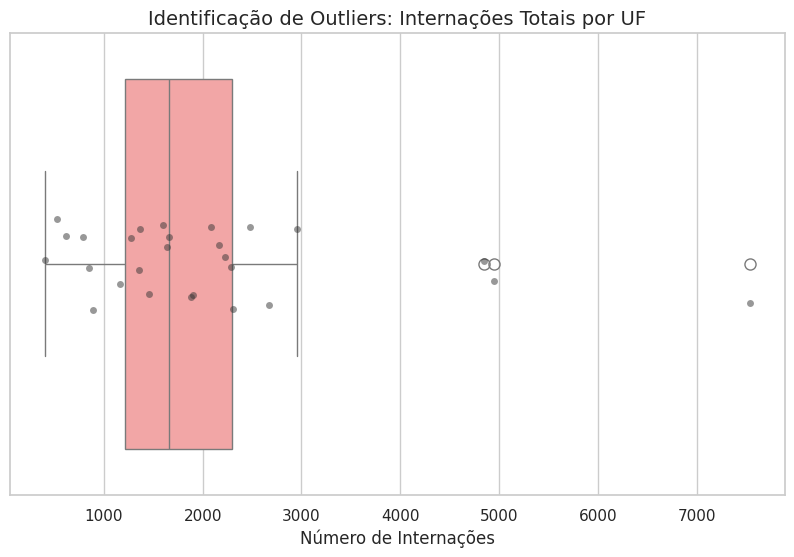

Limite Superior (Corte): 3908.00
Quantidade de Outliers detectados: 3
Estados que são Outliers: ['MA', 'PA', 'PI']


In [153]:
df_final = df_merged.copy()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(x=df_final['Internacao_Total'], color='#ff9999', fliersize=8)
sns.stripplot(x=df_final['Internacao_Total'], color='#333', alpha=0.5) # Adiciona os pontos reais sobre o box

plt.title('Identificação de Outliers: Internações Totais por UF', fontsize=14)
plt.xlabel('Número de Internações')
plt.show()

Q1 = df_final['Internacao_Total'].quantile(0.25)
Q3 = df_final['Internacao_Total'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
outliers_df = df_final[df_final['Internacao_Total'] > limite_superior]

print(f"Limite Superior (Corte): {limite_superior:.2f}")
print(f"Quantidade de Outliers detectados: {len(outliers_df)}")
print(f"Estados que são Outliers: {outliers_df['UF'].tolist()}")

#5. Feature Engineering e Clustering (K-Means)

In [154]:
df_final['Perc_Trat_Convencional'] = df_final['Convencional'] / df_final['Vol_Tratamento_Total']
df_final['Perc_Trat_Nao_Convencional'] = df_final['Nao_Convencional'] / df_final['Vol_Tratamento_Total']
df_final['Perc_Trat_Simples'] = df_final['Simples_Desinfeccao'] / df_final['Vol_Tratamento_Total']
df_final['Perc_Sem_Tratamento'] = df_final['Sem_Tratamento'] / df_final['Vol_Tratamento_Total']

df_final.fillna(0, inplace=True)

X = df_final[['Perc_Trat_Convencional', 'Perc_Trat_Nao_Convencional', 'Perc_Trat_Simples', 'Perc_Sem_Tratamento']]

In [155]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

colunas_score = ['Score_Convencional', 'Score_Nao_Convencional', 'Score_Simples', 'Score_Sem_Tratamento']
df_final[colunas_score] = X_scaled

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = kmeans.fit_predict(df_final[colunas_score])

In [156]:
df_final['ISP'] = (df_final['Score_Convencional'] + df_final['Score_Nao_Convencional'] + df_final['Score_Simples']) - (df_final['Score_Sem_Tratamento'])

temp_mean_isp = df_final.groupby('Cluster')['ISP'].mean().sort_values()

cluster_map = {
    temp_mean_isp.index[0]: 'Risco Alto',
    temp_mean_isp.index[1]: 'Risco Médio',
    temp_mean_isp.index[2]: 'Risco Baixo'
}

df_final['Perfil_Sanitario'] = df_final['Cluster'].map(cluster_map)


In [157]:
df_final[['UF', 'ISP', 'Cluster', 'Perfil_Sanitario']].head(26)

,UF,ISP,Cluster,Perfil_Sanitario
0,AC,-0.025948,0,Risco Médio
1,AL,0.278902,1,Risco Baixo
2,AM,-1.018617,0,Risco Médio
3,AP,-0.071766,0,Risco Médio
4,BA,-0.108075,0,Risco Médio
5,CE,1.544316,1,Risco Baixo
6,DF,0.082230,0,Risco Médio
7,ES,0.156983,0,Risco Médio
8,GO,0.232507,0,Risco Médio
9,MA,-1.040275,2,Risco Alto


In [158]:
df_final.head()

,UF,Estado,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento,Internacao_Feco_Oral,Internacao_Total,Perc_Trat_Convencional,Perc_Trat_Nao_Convencional,Perc_Trat_Simples,Perc_Sem_Tratamento,Score_Convencional,Score_Nao_Convencional,Score_Simples,Score_Sem_Tratamento,Cluster,ISP,Perfil_Sanitario
0,AC,Acre,171337.0,147131.0,0.0,24205.0,0.0,1871.0,2476.0,0.858723,0.000000,0.141271,0.000000,0.919343,-0.748660,-0.669677,-0.473045,0,-0.025948,Risco Médio
1,AL,Alagoas,546898.0,175472.0,66753.0,193953.0,110.0,1351.0,1638.0,0.320850,0.122057,0.354642,0.000201,-1.453556,0.927014,0.333364,-0.472080,1,0.278902,Risco Baixo
2,AM,Amazonas,749550.0,562677.0,8010.0,178863.0,174994.0,1203.0,1362.0,0.750686,0.010686,0.238627,0.233465,0.442726,-0.601951,-0.212013,0.647379,0,-1.018617,Risco Médio
3,AP,Amapá,153640.0,120533.0,0.0,33107.0,2155.0,537.0,791.0,0.784516,0.000000,0.215484,0.014026,0.591969,-0.748660,-0.320807,-0.405732,0,-0.071766,Risco Médio
4,BA,Bahia,2310335.0,1865778.0,147309.0,287568.0,314295.0,1684.0,2304.0,0.807579,0.063761,0.124470,0.136039,0.693715,0.126685,-0.748657,0.179818,0,-0.108075,Risco Médio


In [159]:
df_final.to_excel('df_final.xlsx', index=False)
print('DataFrame df_final salvo com sucesso em df_final.xlsx')

DataFrame df_final salvo com sucesso em df_final.xlsx


### 5.1 Gráfico com todos as regiões

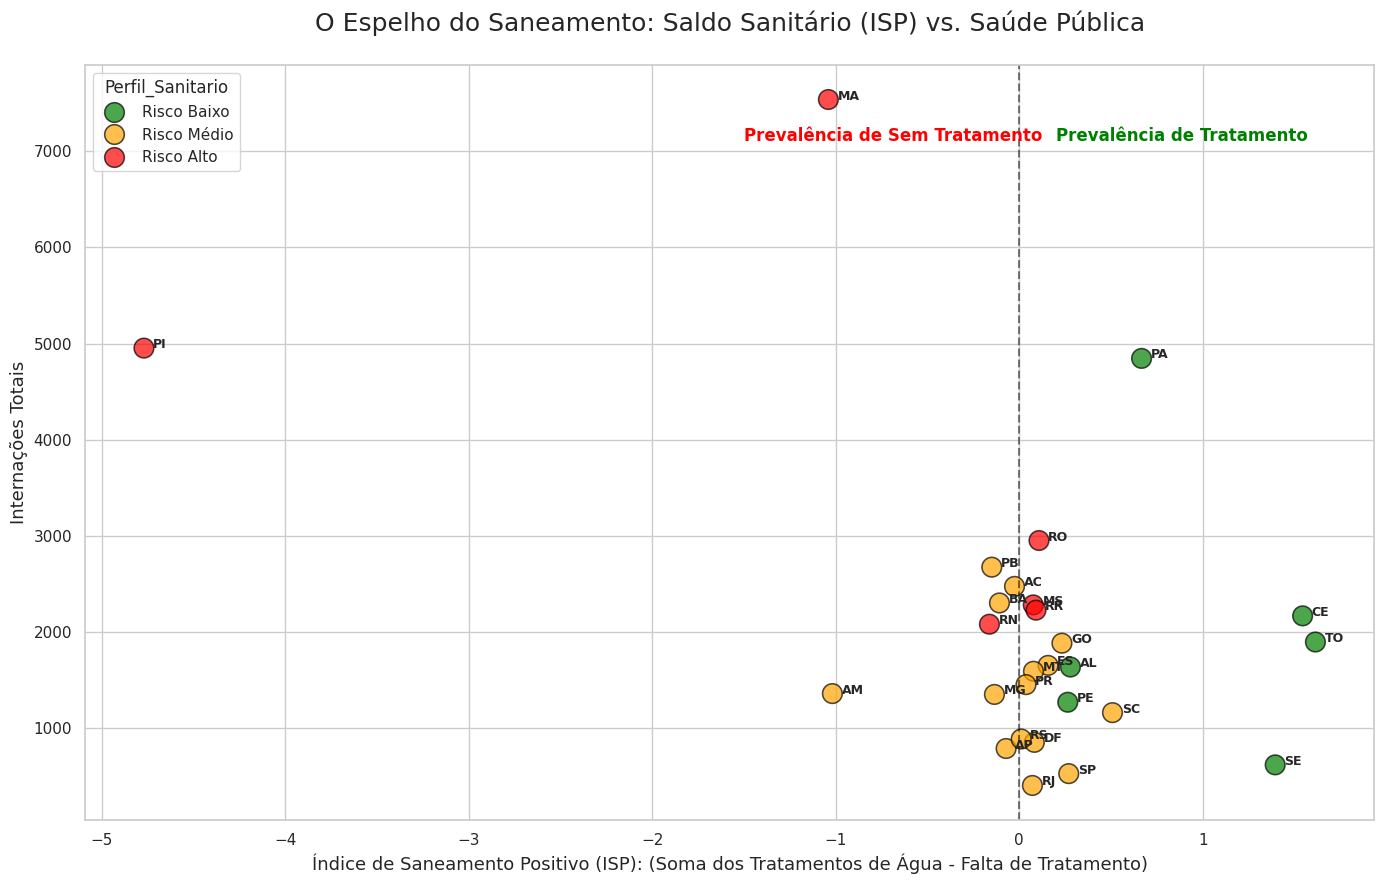


--- RESUMO ESTATÍSTICO DO MODELO ---


,ISP,Internacao_Total
Perfil_Sanitario,,
Risco Baixo,0.960471,2074.166667
Risco Médio,-0.004277,1426.533333
Risco Alto,-0.949779,3673.166667


In [160]:
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

plot = sns.scatterplot(
    data=df_final,
    x='ISP',
    y='Internacao_Total',
    hue='Perfil_Sanitario',
    hue_order=['Risco Baixo', 'Risco Médio', 'Risco Alto'],
    palette={'Risco Baixo': 'green', 'Risco Médio': 'orange', 'Risco Alto': 'red'},
    s=200,
    edgecolor='black',
    alpha=0.7
)


for i in range(df_final.shape[0]):
    plt.text(
        df_final['ISP'].iloc[i] + 0.05,
        df_final['Internacao_Total'].iloc[i],
        df_final['UF'].iloc[i],
        fontsize=9,
        fontweight='bold'
    )

plt.title('O Espelho do Saneamento: Saldo Sanitário (ISP) vs. Saúde Pública', fontsize=18, pad=25)
plt.xlabel('Índice de Saneamento Positivo (ISP): (Soma dos Tratamentos de Água - Falta de Tratamento)', fontsize=13)
plt.ylabel('Internações Totais', fontsize=13)

# Linha vertical no zero: Separa quem tem saldo positivo de tratamento de quem tem saldo negativo
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.text(0.2, plt.gca().get_ylim()[1]*0.9, 'Prevalência de Tratamento', color='green', fontweight='bold')
plt.text(-1.5, plt.gca().get_ylim()[1]*0.9, 'Prevalência de Sem Tratamento', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- RESUMO ESTATÍSTICO DO MODELO ---")

resumo = df_final.groupby('Perfil_Sanitario').agg({
    'ISP': 'mean',
    'Internacao_Total': 'mean'
}).sort_values('ISP', ascending=False)

display(resumo)

# 6. Isolation Forest:
Objetivo? Isolar outliers e estudar os registros que tem o mesmo padrão de comportamento, uma vez que o modelo de clusterização K-Means é sensível a outliers. Fazer comparação.

In [161]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.11, random_state=42)

# Treinando o modelo
df_final['Outlier_IF'] = iso_forest.fit_predict(df_final[['ISP', 'Internacao_Total']])

df_padrao = df_final[df_final['Outlier_IF'] == 1]
df_critico = df_final[df_final['Outlier_IF'] == -1]

print(f"Análise concluída. {len(df_critico)} estados movidos para a zona crítica.")

Análise concluída. 3 estados movidos para a zona crítica.


In [162]:
resumo_limpo = df_padrao.groupby('Perfil_Sanitario')[['ISP', 'Internacao_Total']].mean().sort_values(by='ISP', ascending=False)

print("--- NOVO RESUMO ESTATÍSTICO (SEM OUTLIERS) ---")
print(resumo_limpo)

print("\n--- ESTADOS ISOLADOS PELO ISOLATION FOREST ---")
print(df_final[df_final['Outlier_IF'] == -1][['UF', 'ISP', 'Internacao_Total']])

--- NOVO RESUMO ESTATÍSTICO (SEM OUTLIERS) ---
                       ISP  Internacao_Total
Perfil_Sanitario                            
Risco Baixo       1.019248       1519.800000
Risco Alto        0.028010       2387.250000
Risco Médio      -0.004277       1426.533333

--- ESTADOS ISOLADOS PELO ISOLATION FOREST ---
    UF       ISP  Internacao_Total
9   MA -1.040275            7537.0
13  PA  0.666585            4846.0
16  PI -4.770439            4953.0


In [163]:
df_padrao.head()

,UF,Estado,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento,Internacao_Feco_Oral,Internacao_Total,Perc_Trat_Convencional,...,Perc_Trat_Simples,Perc_Sem_Tratamento,Score_Convencional,Score_Nao_Convencional,Score_Simples,Score_Sem_Tratamento,Cluster,ISP,Perfil_Sanitario,Outlier_IF
0,AC,Acre,171337.0,147131.0,0.0,24205.0,0.0,1871.0,2476.0,0.858723,...,0.141271,0.000000,0.919343,-0.748660,-0.669677,-0.473045,0,-0.025948,Risco Médio,1
1,AL,Alagoas,546898.0,175472.0,66753.0,193953.0,110.0,1351.0,1638.0,0.320850,...,0.354642,0.000201,-1.453556,0.927014,0.333364,-0.472080,1,0.278902,Risco Baixo,1
2,AM,Amazonas,749550.0,562677.0,8010.0,178863.0,174994.0,1203.0,1362.0,0.750686,...,0.238627,0.233465,0.442726,-0.601951,-0.212013,0.647379,0,-1.018617,Risco Médio,1
3,AP,Amapá,153640.0,120533.0,0.0,33107.0,2155.0,537.0,791.0,0.784516,...,0.215484,0.014026,0.591969,-0.748660,-0.320807,-0.405732,0,-0.071766,Risco Médio,1
4,BA,Bahia,2310335.0,1865778.0,147309.0,287568.0,314295.0,1684.0,2304.0,0.807579,...,0.124470,0.136039,0.693715,0.126685,-0.748657,0.179818,0,-0.108075,Risco Médio,1


# 7. Remover coluna 'Outlier_IF' do frame 'df_padrao'
O df_padrao não pode ter essa coluna para o próximo passo que é a visualização gráfica dos dados

In [164]:
df_padrao.drop(columns=['Outlier_IF'], inplace=True)
df_padrao.head()

/tmp/ipykernel_514/755722064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_padrao.drop(columns=['Outlier_IF'], inplace=True)


,UF,Estado,Vol_Tratamento_Total,Convencional,Nao_Convencional,Simples_Desinfeccao,Sem_Tratamento,Internacao_Feco_Oral,Internacao_Total,Perc_Trat_Convencional,Perc_Trat_Nao_Convencional,Perc_Trat_Simples,Perc_Sem_Tratamento,Score_Convencional,Score_Nao_Convencional,Score_Simples,Score_Sem_Tratamento,Cluster,ISP,Perfil_Sanitario
0,AC,Acre,171337.0,147131.0,0.0,24205.0,0.0,1871.0,2476.0,0.858723,0.000000,0.141271,0.000000,0.919343,-0.748660,-0.669677,-0.473045,0,-0.025948,Risco Médio
1,AL,Alagoas,546898.0,175472.0,66753.0,193953.0,110.0,1351.0,1638.0,0.320850,0.122057,0.354642,0.000201,-1.453556,0.927014,0.333364,-0.472080,1,0.278902,Risco Baixo
2,AM,Amazonas,749550.0,562677.0,8010.0,178863.0,174994.0,1203.0,1362.0,0.750686,0.010686,0.238627,0.233465,0.442726,-0.601951,-0.212013,0.647379,0,-1.018617,Risco Médio
3,AP,Amapá,153640.0,120533.0,0.0,33107.0,2155.0,537.0,791.0,0.784516,0.000000,0.215484,0.014026,0.591969,-0.748660,-0.320807,-0.405732,0,-0.071766,Risco Médio
4,BA,Bahia,2310335.0,1865778.0,147309.0,287568.0,314295.0,1684.0,2304.0,0.807579,0.063761,0.124470,0.136039,0.693715,0.126685,-0.748657,0.179818,0,-0.108075,Risco Médio


# 8. Gráfico sem outliers

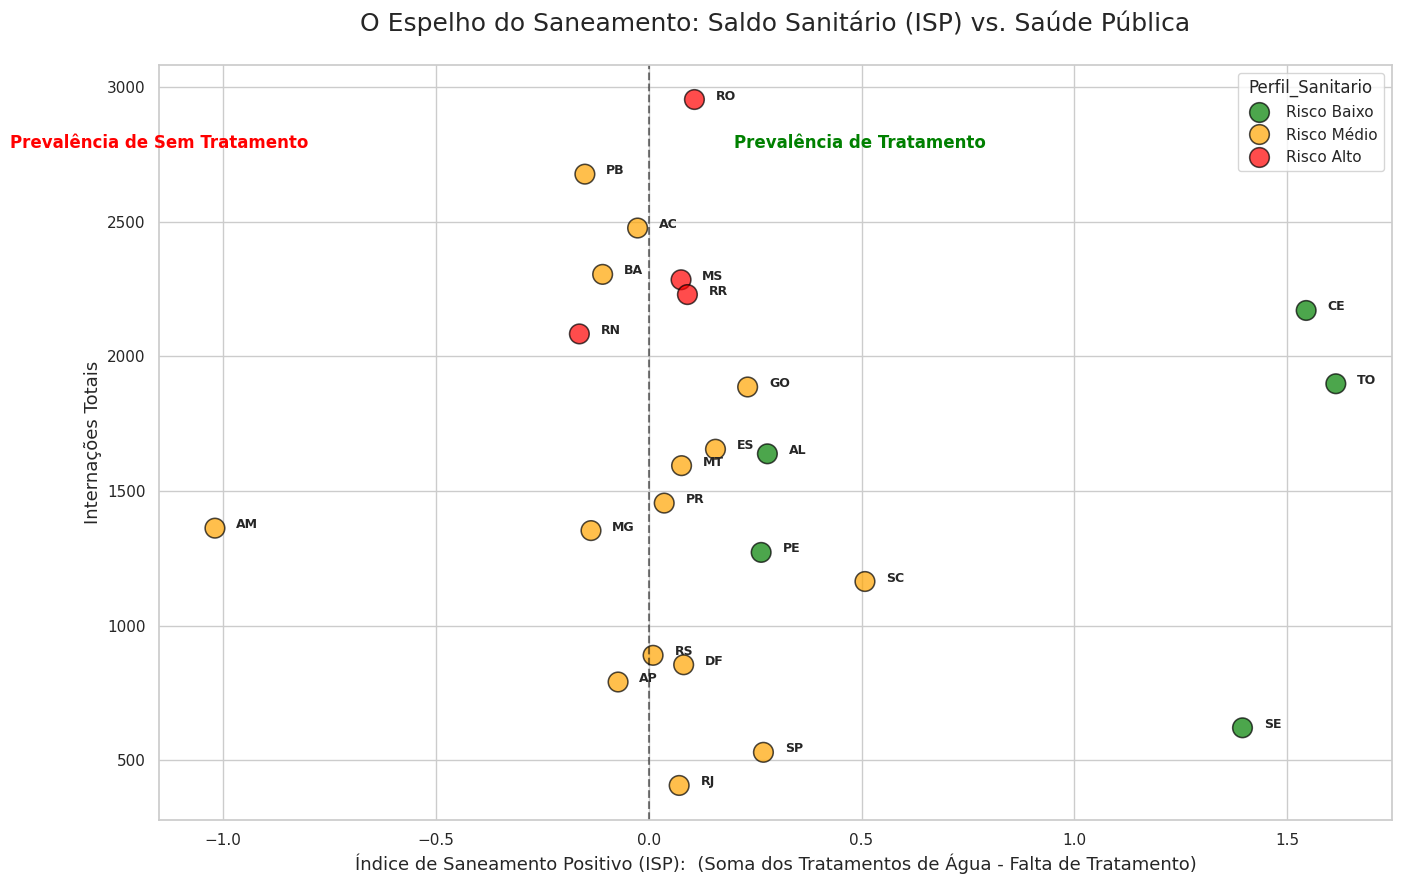

In [165]:
plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

plot = sns.scatterplot(
    data=df_padrao,
    x='ISP',
    y='Internacao_Total',
    hue='Perfil_Sanitario',
    hue_order=['Risco Baixo', 'Risco Médio', 'Risco Alto'],
    palette={'Risco Baixo': 'green', 'Risco Médio': 'orange', 'Risco Alto': 'red'},
    s=200,
    edgecolor='black',
    alpha=0.7
)

for i in range(df_padrao.shape[0]):
    plt.text(
        df_padrao['ISP'].iloc[i] + 0.05,
        df_padrao['Internacao_Total'].iloc[i],
        df_padrao['UF'].iloc[i],
        fontsize=9,
        fontweight='bold'
    )

plt.title('O Espelho do Saneamento: Saldo Sanitário (ISP) vs. Saúde Pública', fontsize=18, pad=25)
plt.xlabel('Índice de Saneamento Positivo (ISP):  (Soma dos Tratamentos de Água - Falta de Tratamento)', fontsize=13)
plt.ylabel('Internações Totais', fontsize=13)

# Linha vertical no zero: Separa quem tem saldo positivo de tratamento de quem tem saldo negativo
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.text(0.2, plt.gca().get_ylim()[1]*0.9, 'Prevalência de Tratamento', color='green', fontweight='bold')
plt.text(-1.5, plt.gca().get_ylim()[1]*0.9, 'Prevalência de Sem Tratamento', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

# Considerações

### Mesmo retirando os outliers, visualmente nota-se que o comportamento geral se manteve. Todavia, apesar da limitação dos algoritmos, a grande maioria dos casos em que o ISP foi positivo, o risco de internação foi baixo, salvo exceções. Vamos observar duas regiões (CE) e (AM):
-  O estado do Amazonas (AM) teve indice ISP negativo, foi agrupado como uma região de risco medio. Todavia, embora o ISP seja negativo, o numero de internações em relação aos outros estados foi menor.
- O estado do Ceará (CE) teve indice ISP positivo, foi agrupado como baixo risco, no entanto o número de internações é alto.

### Conclusão: O tratamento de água é fundamental para um saneamento básico de qualidade nas cidades e esse fator tem influência no número de doenças e casos de internações, porém o saneamento abrange uma gama de áreas e obviamente não é apenas ele o fator preponderante na ocorrência desse fenomeno, mas ainda assim os dados provaram que existe uma ligação inversamente proporcional, como podemos observar nos estados SP, RJ, DF, PE, RS, PR, AL, GO, MT, ES, SE, TO que tiveram um ISP positivo com menos de 2000 internações totais.

In [166]:
#df_final.to_excel('df_final.xlsx', index=False)
#print('DataFrame df_final salvo com sucesso em df_final.xlsx')